# Coffee Dialling Automation Algorithm
## Arabica Coffee Quality Analysis
### Data Source: Coffee Quality Institute (CQI)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Load dataset
df = pd.read_csv("Arabica.csv", encoding="latin1")

# Rename for easier handling
df = df.rename(columns={'Country/Region of Origin': 'Country'})

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Shape: (207, 37)

Columns:
['ID', 'Country', 'Farm Name', 'Lot Number', 'Mill', 'ICO Number', 'Company', 'Altitude', 'Region', 'Producer', 'Number of Bags', 'Bag Weight', 'In-Country Partner', 'Harvest Year', 'Grading Date', 'Owner', 'Variety', 'Status', 'Processing Method', 'Aroma', 'Flavor', 'Aftertaste', 'Acidity', 'Body', 'Balance', 'Uniformity', 'Clean Cup', 'Sweetness', 'Overall', 'Defects', 'Total Cup Points', 'Moisture Percentage', 'Category One Defects', 'Quakers', 'Color', 'Category Two Defects', 'Expiration']


## Step 1: Select and Clean Sensory Features


In [2]:
sensory_features = ['Aroma', 'Flavor', 'Aftertaste', 'Acidity', 'Body', 'Balance']

# Check sensory features
print("Sensory Features Summary:")
print(df[sensory_features].describe().round(3))

print("\nMissing values:")
print(df[sensory_features].isnull().sum())

Sensory Features Summary:
         Aroma   Flavor  Aftertaste  Acidity     Body  Balance
count  207.000  207.000     207.000  207.000  207.000  207.000
mean     7.721    7.745       7.600    7.690    7.641    7.644
std      0.288    0.280       0.276    0.260    0.233    0.256
min      6.500    6.750       6.670    6.830    6.830    6.670
25%      7.580    7.580       7.420    7.500    7.500    7.500
50%      7.670    7.750       7.580    7.670    7.670    7.670
75%      7.920    7.920       7.750    7.875    7.750    7.790
max      8.580    8.500       8.420    8.580    8.250    8.420

Missing values:
Aroma         0
Flavor        0
Aftertaste    0
Acidity       0
Body          0
Balance       0
dtype: int64


## Step 2: Scale the Sensory Features

In [3]:
from sklearn.preprocessing import StandardScaler

X_cluster = df[sensory_features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

print("Shape:", X_scaled.shape)
print("\nMean of each feature after scaling (should be ~0):")
print(X_scaled.mean(axis=0).round(3))
print("\nStd of each feature after scaling (should be ~1):")
print(X_scaled.std(axis=0).round(3))

Shape: (207, 6)

Mean of each feature after scaling (should be ~0):
[-0. -0. -0.  0. -0.  0.]

Std of each feature after scaling (should be ~1):
[1. 1. 1. 1. 1. 1.]


## Step 3: Find Optimal Number of Clusters — Elbow Plot


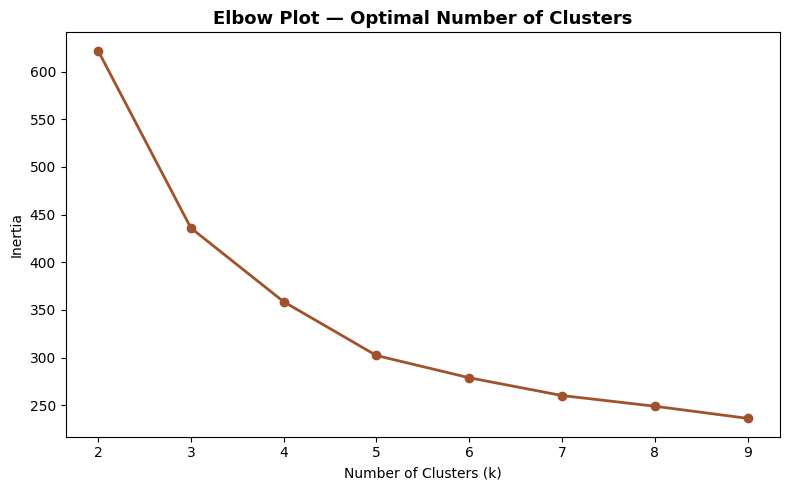

Inertia values:
  k=2: 621.84
  k=3: 435.98
  k=4: 358.67
  k=5: 302.29
  k=6: 278.96
  k=7: 260.33
  k=8: 249.11
  k=9: 236.40


In [4]:
inertia = []
k_range = range(2, 10)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o', color='sienna', linewidth=2)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Plot — Optimal Number of Clusters', fontsize=13, fontweight='bold')
plt.xticks(k_range)
plt.tight_layout()
plt.savefig("elbow_plot.png", dpi=300, bbox_inches="tight")
plt.show()

print("Inertia values:")
for k, val in zip(k_range, inertia):
    print(f"  k={k}: {val:.2f}")

## Step 4: Confirm with Silhouette Score

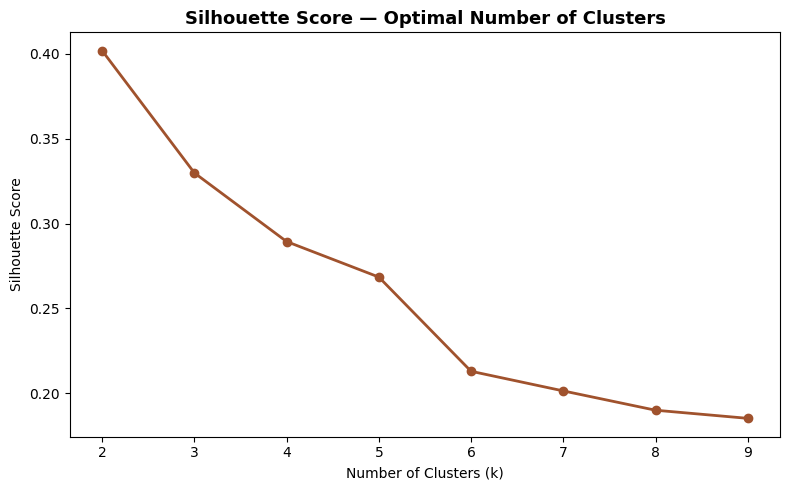

Silhouette scores:
  k=2: 0.4019
  k=3: 0.3298
  k=4: 0.2894
  k=5: 0.2684
  k=6: 0.2129
  k=7: 0.2013
  k=8: 0.1900
  k=9: 0.1852


In [5]:
silhouette_scores = []

for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 10), silhouette_scores, marker='o', color='sienna', linewidth=2)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score — Optimal Number of Clusters', fontsize=13, fontweight='bold')
plt.xticks(range(2, 10))
plt.tight_layout()
plt.savefig("silhouette_plot.png", dpi=300, bbox_inches="tight")
plt.show()

print("Silhouette scores:")
for k, val in zip(range(2, 10), silhouette_scores):
    print(f"  k={k}: {val:.4f}")

## Step 5: Run KMeans with k=3

In [6]:
km_final = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = km_final.fit_predict(X_scaled)

print("Cluster distribution:")
print(df['Cluster'].value_counts().sort_index())

print("\nFirst 5 rows with cluster labels:")
print(df[sensory_features + ['Cluster']].head())

Cluster distribution:
Cluster
0     66
1     41
2    100
Name: count, dtype: int64

First 5 rows with cluster labels:
   Aroma  Flavor  Aftertaste  Acidity  Body  Balance  Cluster
0   8.58    8.50        8.42     8.58  8.25     8.42        0
1   8.50    8.50        7.92     8.00  7.92     8.25        0
2   8.33    8.42        8.08     8.17  7.92     8.17        0
3   8.08    8.17        8.17     8.25  8.17     8.08        0
4   8.33    8.33        8.08     8.25  7.92     7.92        0


## Step 6: Profile Each Cluster

In [7]:
cluster_profiles = df.groupby('Cluster')[sensory_features].mean().round(3)

print("=== Average Sensory Scores per Cluster ===")
print(cluster_profiles)

print("\n=== Overall score per cluster ===")
print(df.groupby('Cluster')['Overall'].mean().round(3))

=== Average Sensory Scores per Cluster ===
         Aroma  Flavor  Aftertaste  Acidity   Body  Balance
Cluster                                                    
0        7.996   8.026       7.883    7.940  7.849    7.903
1        7.385   7.367       7.254    7.352  7.327    7.291
2        7.678   7.714       7.555    7.664  7.632    7.618

=== Overall score per cluster ===
Cluster
0    7.978
1    7.287
2    7.638
Name: Overall, dtype: float64


## Step 7: Name the Clusters

In [8]:
cluster_names = {
    0: 'Premium',
    2: 'Standard',
    1: 'Below Average'
}

df['Cluster Name'] = df['Cluster'].map(cluster_names)

print("Cluster counts with names:")
print(df['Cluster Name'].value_counts())

Cluster counts with names:
Cluster Name
Standard         100
Premium           66
Below Average     41
Name: count, dtype: int64


## Step 8: Radar Chart — Flavour Profiles

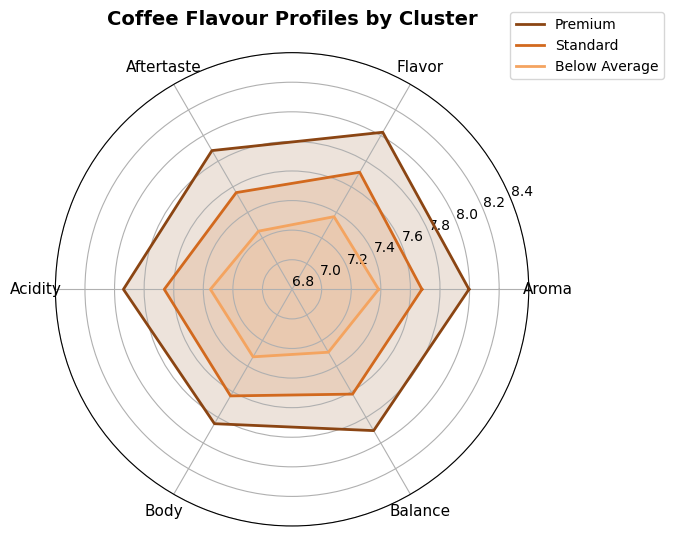

In [9]:
from matplotlib.patches import FancyArrowPatch
import numpy as np

categories = sensory_features
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

cluster_order = [0, 2, 1]
colors = ['#8B4513', '#D2691E', '#F4A460']
names = ['Premium', 'Standard', 'Below Average']

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

for cluster_id, color, name in zip(cluster_order, colors, names):
    values = cluster_profiles.loc[cluster_id].tolist()
    values += values[:1]
    ax.plot(angles, values, color=color, linewidth=2, label=name)
    ax.fill(angles, values, color=color, alpha=0.15)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=11)
ax.set_ylim(6.8, 8.4)
ax.set_title('Coffee Flavour Profiles by Cluster',
             size=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.savefig("radar_cluster_profiles.png", dpi=300, bbox_inches="tight")
plt.show()

## Step 9: Which Countries Fall Into Which Cluster?

In [10]:
country_cluster = df.groupby(['Country', 'Cluster Name']).size().unstack(fill_value=0)

print("=== Country vs Cluster Distribution ===")
print(country_cluster)

=== Country vs Cluster Distribution ===
Cluster Name                  Below Average  Premium  Standard
Country                                                       
Brazil                                    6        2         2
Colombia                                  3        4        12
Costa Rica                                2        1         5
El Salvador                               3        0         4
Ethiopia                                  0        6         5
Guatemala                                 2        8        11
Honduras                                  1        1        11
Indonesia                                 1        1         1
Kenya                                     1        1         0
Laos                                      1        1         1
Madagascar                                0        0         1
Mexico                                    1        0         3
Myanmar                                   0        0         1
Nicaragua      

## Step 10: Visualise Country vs Cluster

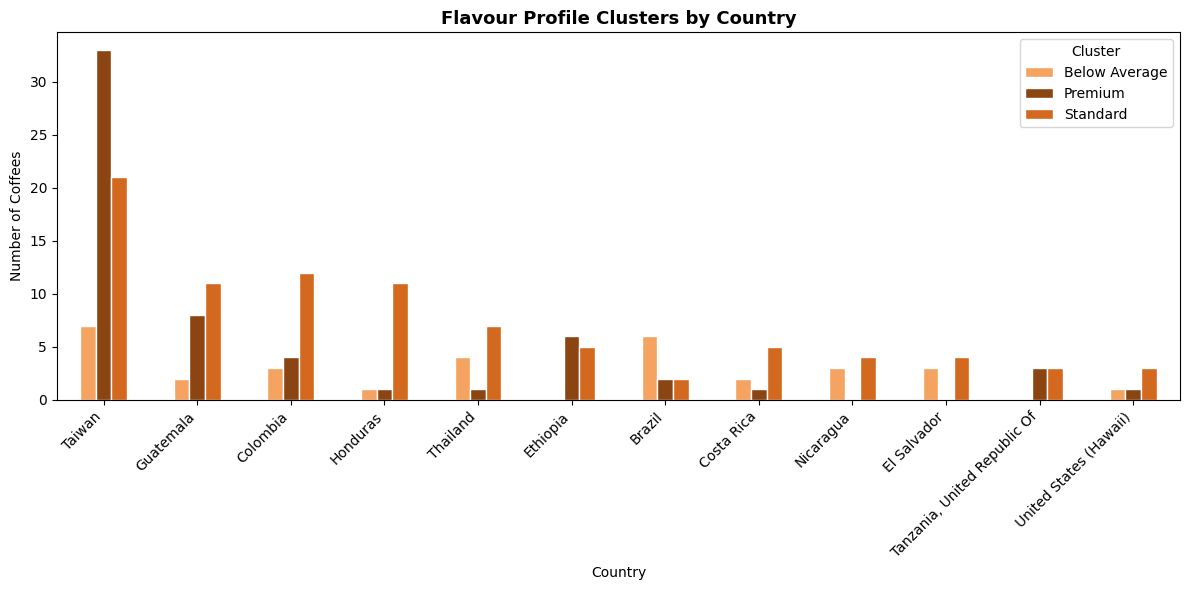

In [11]:
# Only show countries with at least 5 samples
country_counts = df['Country'].value_counts()
valid_countries = country_counts[country_counts >= 5].index

country_cluster_filtered = country_cluster.loc[valid_countries]

country_cluster_filtered.plot(
    kind='bar',
    figsize=(12, 6),
    color=['#F4A460', '#8B4513', '#D2691E'],
    edgecolor='white'
)

plt.title('Flavour Profile Clusters by Country', fontsize=13, fontweight='bold')
plt.xlabel('Country')
plt.ylabel('Number of Coffees')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Cluster')
plt.tight_layout()
plt.savefig("country_cluster_chart.png", dpi=300, bbox_inches="tight")
plt.show()

## Step 11: Processing Method vs Cluster

=== Processing Method vs Cluster ===
Cluster Name       Below Average  Premium  Standard
Processing Simple                                  
Honey                          7        8        11
Natural                       10       19        18
Other                          0        3         4
Washed                        24       36        67


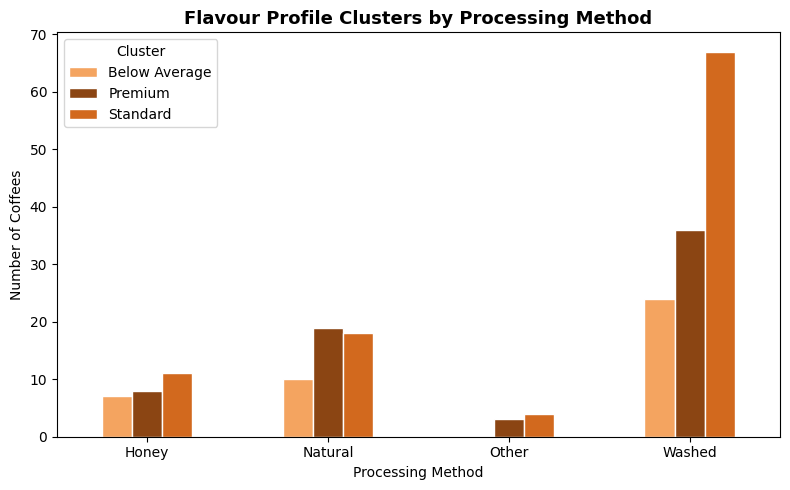

In [12]:
# Simplify processing method
def simplify_processing(value):
    value = str(value).lower().strip()
    if 'washed' in value or 'lavado' in value:
        return 'Washed'
    elif 'honey' in value:
        return 'Honey'
    elif 'natural' in value or 'dry' in value:
        return 'Natural'
    else:
        return 'Other'

df['Processing Simple'] = df['Processing Method'].apply(simplify_processing)

process_cluster = df.groupby(['Processing Simple', 'Cluster Name']).size().unstack(fill_value=0)

print("=== Processing Method vs Cluster ===")
print(process_cluster)

process_cluster.plot(
    kind='bar',
    figsize=(8, 5),
    color=['#F4A460', '#8B4513', '#D2691E'],
    edgecolor='white'
)

plt.title('Flavour Profile Clusters by Processing Method', fontsize=13, fontweight='bold')
plt.xlabel('Processing Method')
plt.ylabel('Number of Coffees')
plt.xticks(rotation=0)
plt.legend(title='Cluster')
plt.tight_layout()
plt.savefig("processing_cluster_chart.png", dpi=300, bbox_inches="tight")
plt.show()

## Step 12: Defects vs Cluster

=== Average Defects per Cluster ===
               Category One Defects  Category Two Defects
Cluster Name                                             
Below Average                 0.146                 3.317
Premium                       0.030                 1.061
Standard                      0.200                 2.600


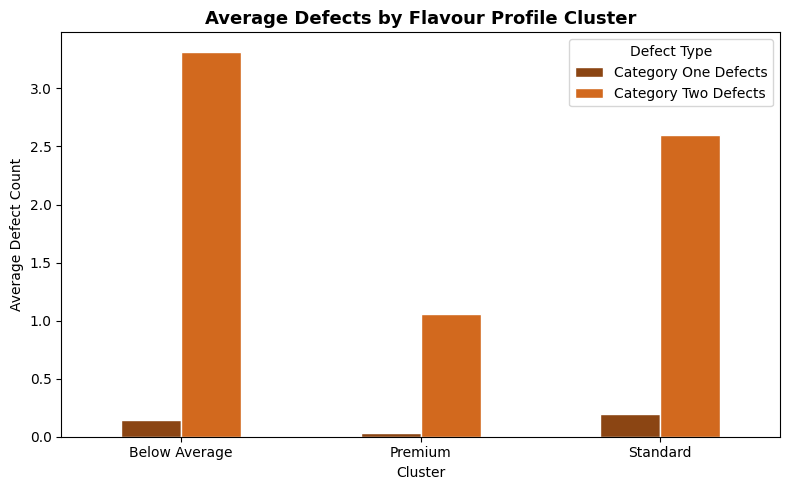

In [13]:
defect_cluster = df.groupby('Cluster Name')[['Category One Defects', 'Category Two Defects']].mean().round(3)

print("=== Average Defects per Cluster ===")
print(defect_cluster)

defect_cluster.plot(
    kind='bar',
    figsize=(8, 5),
    color=['#8B4513', '#D2691E'],
    edgecolor='white'
)

plt.title('Average Defects by Flavour Profile Cluster', fontsize=13, fontweight='bold')
plt.xlabel('Cluster')
plt.ylabel('Average Defect Count')
plt.xticks(rotation=0)
plt.legend(title='Defect Type')
plt.tight_layout()
plt.savefig("defect_cluster_chart.png", dpi=300, bbox_inches="tight")
plt.show()


# Final Download Cell
## Downloads all important CSVs and all required PNG charts


In [14]:
from google.colab import files
import pandas as pd
import matplotlib.pyplot as plt
import os
import zipfile


# ---------- Save important CSVs ----------

df.to_csv("final_dataset_with_clusters.csv", index=False)
cluster_profiles.to_csv("cluster_profiles.csv")
country_cluster_filtered.to_csv("country_cluster_analysis.csv")
process_cluster.to_csv("processing_cluster_analysis.csv")
defect_cluster.to_csv("defect_cluster_analysis.csv")

essential_columns = sensory_features + [
    "Overall",
    "Country",
    "Processing Method",
    "Processing Simple",
    "Category One Defects",
    "Category Two Defects",
    "Cluster",
    "Cluster Name"
]

important_features_df = df[essential_columns]
important_features_df.to_csv("important_features_with_clusters.csv", index=False)

df["Cluster Name"].value_counts().to_csv("cluster_distribution.csv")


# ---------- Make sure all required charts exist as PNG files ----------
# If a chart cell was not rerun, this final cell recreates the PNG file from existing variables.

# 1. Elbow plot
if not os.path.exists("elbow_plot.png"):
    plt.figure(figsize=(8, 5))
    plt.plot(k_range, inertia, marker="o", color="sienna", linewidth=2)
    plt.xlabel("Number of Clusters (k)")
    plt.ylabel("Inertia")
    plt.title("Elbow Plot — Optimal Number of Clusters", fontsize=13, fontweight="bold")
    plt.xticks(k_range)
    plt.tight_layout()
    plt.savefig("elbow_plot.png", dpi=300, bbox_inches="tight")
    plt.close()

# 2. Silhouette plot
if not os.path.exists("silhouette_plot.png"):
    plt.figure(figsize=(8, 5))
    plt.plot(range(2, 10), silhouette_scores, marker="o", color="sienna", linewidth=2)
    plt.xlabel("Number of Clusters (k)")
    plt.ylabel("Silhouette Score")
    plt.title("Silhouette Score — Optimal Number of Clusters", fontsize=13, fontweight="bold")
    plt.xticks(range(2, 10))
    plt.tight_layout()
    plt.savefig("silhouette_plot.png", dpi=300, bbox_inches="tight")
    plt.close()

# 3. Radar chart
if not os.path.exists("radar_cluster_profiles.png"):
    import numpy as np

    categories = sensory_features
    N = len(categories)
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1]

    cluster_order = [0, 2, 1]
    colors = ["#8B4513", "#D2691E", "#F4A460"]
    names = ["Premium", "Standard", "Below Average"]

    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

    for cluster_id, color, name in zip(cluster_order, colors, names):
        values = cluster_profiles.loc[cluster_id].tolist()
        values += values[:1]
        ax.plot(angles, values, color=color, linewidth=2, label=name)
        ax.fill(angles, values, color=color, alpha=0.15)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, size=11)
    ax.set_ylim(6.8, 8.4)
    ax.set_title("Coffee Flavour Profiles by Cluster", size=14, fontweight="bold", pad=20)
    ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
    plt.tight_layout()
    plt.savefig("radar_cluster_profiles.png", dpi=300, bbox_inches="tight")
    plt.close()

# 4. Country cluster chart
if not os.path.exists("country_cluster_chart.png"):
    country_cluster_filtered.plot(
        kind="bar",
        figsize=(12, 6),
        color=["#F4A460", "#8B4513", "#D2691E"],
        edgecolor="white"
    )
    plt.title("Flavour Profile Clusters by Country", fontsize=13, fontweight="bold")
    plt.xlabel("Country")
    plt.ylabel("Number of Coffees")
    plt.xticks(rotation=45, ha="right")
    plt.legend(title="Cluster")
    plt.tight_layout()
    plt.savefig("country_cluster_chart.png", dpi=300, bbox_inches="tight")
    plt.close()

# 5. Processing method chart
if not os.path.exists("processing_cluster_chart.png"):
    process_cluster.plot(
        kind="bar",
        figsize=(8, 5),
        color=["#F4A460", "#8B4513", "#D2691E"],
        edgecolor="white"
    )
    plt.title("Flavour Profile Clusters by Processing Method", fontsize=13, fontweight="bold")
    plt.xlabel("Processing Method")
    plt.ylabel("Number of Coffees")
    plt.xticks(rotation=0)
    plt.legend(title="Cluster")
    plt.tight_layout()
    plt.savefig("processing_cluster_chart.png", dpi=300, bbox_inches="tight")
    plt.close()

# 6. Defect chart
if not os.path.exists("defect_cluster_chart.png"):
    defect_cluster.plot(
        kind="bar",
        figsize=(8, 5),
        color=["#8B4513", "#D2691E"],
        edgecolor="white"
    )
    plt.title("Average Defects by Flavour Profile Cluster", fontsize=13, fontweight="bold")
    plt.xlabel("Cluster")
    plt.ylabel("Average Defect Count")
    plt.xticks(rotation=0)
    plt.legend(title="Defect Type")
    plt.tight_layout()
    plt.savefig("defect_cluster_chart.png", dpi=300, bbox_inches="tight")
    plt.close()


# ---------- Zip everything and download once ----------

csv_files = [
    "final_dataset_with_clusters.csv",
    "important_features_with_clusters.csv",
    "cluster_profiles.csv",
    "country_cluster_analysis.csv",
    "processing_cluster_analysis.csv",
    "defect_cluster_analysis.csv",
    "cluster_distribution.csv"
]

chart_files = [
    "elbow_plot.png",
    "silhouette_plot.png",
    "radar_cluster_profiles.png",
    "country_cluster_chart.png",
    "processing_cluster_chart.png",
    "defect_cluster_chart.png"
]

output_files = csv_files + chart_files

zip_name = "CDA_Clustering_Final_Outputs.zip"

with zipfile.ZipFile(zip_name, "w") as zipf:
    for file in output_files:
        if os.path.exists(file):
            zipf.write(file)
        else:
            print("Missing:", file)

files.download(zip_name)

print("Done. Downloaded one ZIP containing all CSVs and all PNG charts.")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Done. Downloaded one ZIP containing all CSVs and all PNG charts.
